# TP2 - Gaussian Mixture Models

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from sklearn.datasets import load_digits
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split


## A. Données 1D

### 1) Génération des données

In [4]:
N = 100
X = np.concatenate((np.random.normal(0, 1, int(0.3*N)),
        np.random.normal(5, 1, int(0.7*N))))[:, np.newaxis]

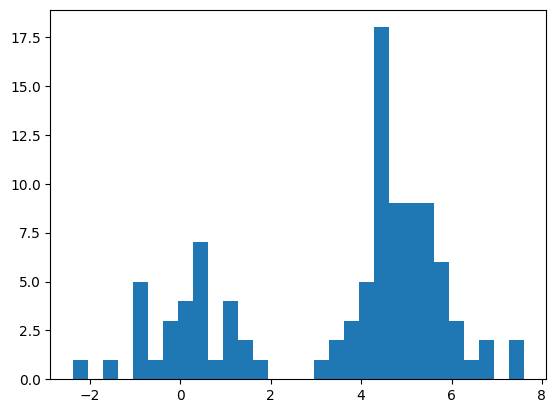

In [12]:
plt.hist(X, bins=30)
plt.show()

### 2) Apprentissage du modèle de mélange

In [6]:
gmm = GaussianMixture(n_components=2, random_state=1)
gmm.fit(X)

GaussianMixture(n_components=2, random_state=1)

In [8]:
x = np.linspace(-5, 10, 1000).reshape(-1, 1)
logprob = gmm.score_samples(x)
pdf_gmm = np.exp(logprob)

# Densités réelles
pdf_true = 0.3 * norm.pdf(x, 0, 1) + 0.7 * norm.pdf(x, 5, 1)

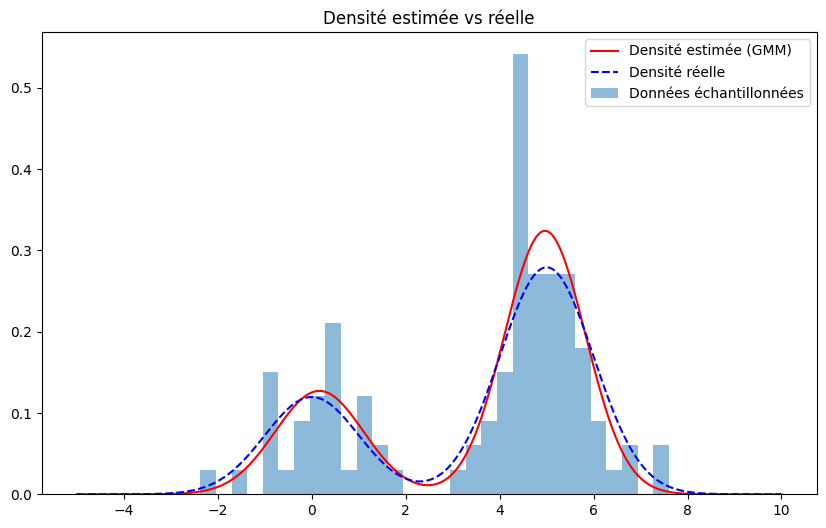

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(x, pdf_gmm, label='Densité estimée (GMM)', color='red')
plt.plot(x, pdf_true, label='Densité réelle', color='blue', linestyle='dashed')
plt.hist(X, bins=30, density=True, alpha=0.5, label='Données échantillonnées')
plt.title('Densité estimée vs réelle')
plt.legend()
plt.show()

In [17]:
print(f'moyenne du gmm : {gmm.means_.flatten()}')
print(f'poids du gmm : {gmm.weights_}')

moyenne du gmm : [0.16111456 4.96443916]
poids du gmm : [0.29994993 0.70005007]


In [ ]:
score = []
for i in range(3, 10):
    gmm2 = GaussianMixture(n_components=i, random_state=1)
    gmm2.fit(X)

    log = gmm2.score_samples(x)
    pdf_ = np.exp(log)

    print(f'nombre de composante : {i}')
    print(f'moyenne du gmm : {gmm2.means_.flatten()}')
    print(f'poids du gmm : {gmm2.weights_}')
    print(f'score : {gmm2.score(X)}')
    score.append(gmm2.score(X))
    plt.figure(figsize=(10, 6))
    plt.plot(x, pdf_, label='Densité estimée (GMM)', color='red')
    plt.hist(X, bins=30, density=True, alpha=0.5, label='Données échantillonnées')
    plt.title(f'Densité estimée pour {i} composante')
    plt.legend()
    plt.show()


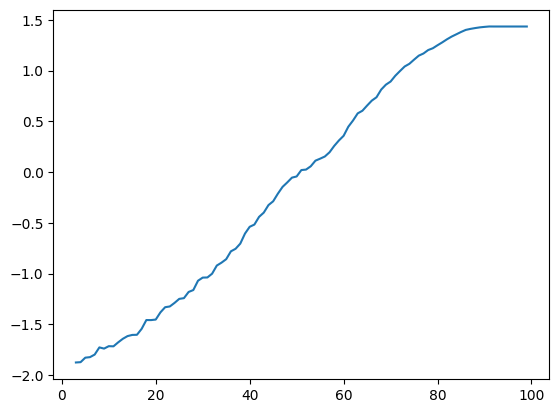

In [23]:
plt.plot(range(3, 10), score)

## B. Données 2D

### 1) Génération des données

In [24]:
md1 = 1.5 * np.random.randn(200, 2) + [3, 3]
md2 = np.random.randn(100, 2).dot([[2, 0], [0, 0.8]]) + [-3, 3]
md3 = np.random.randn(100, 2) + [3, -3]
md = np.concatenate((md1, md2, md3))

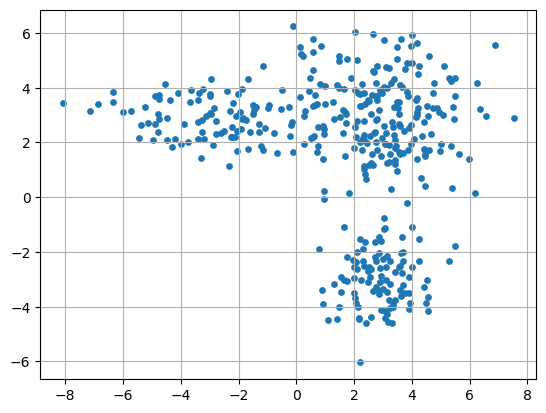

In [54]:
plt.scatter(md[:,0], md[:, 1], s=15)
plt.grid(True)
plt.show()

In [62]:
gmm2D = GaussianMixture(n_components=3, random_state=1)
gmm2D.fit(md)

In [66]:
x, y = np.meshgrid(np.linspace(-10, 10, 100), np.linspace(-10, 10, 100))
xy = np.array([x.ravel(), y.ravel()]).T

# Calcul de la log-vraisemblance pour chaque point de la grille
log_density = gmm2D.score_samples(xy)
density = np.exp(log_density).reshape(x.shape)

In [78]:
print(f'moyenne : {gmm2D.means_}')
print(f'poids : {gmm2D.weights_}')

moyenne : [[ 2.92233273  3.04816955]
 [ 2.88199544 -2.99266154]
 [-2.86113546  2.85990105]]
poids : [0.51115299 0.25140357 0.23744344]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


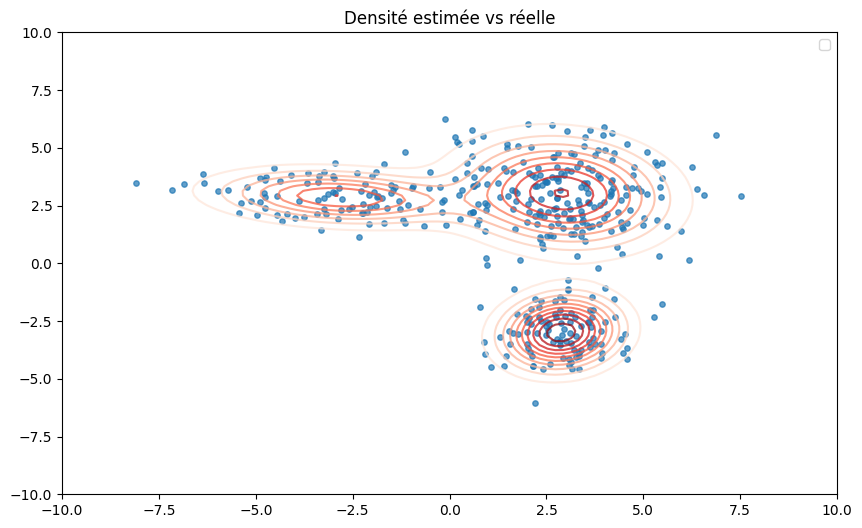

In [67]:
plt.figure(figsize=(10, 6))
plt.scatter(md[:,0], md[:, 1], alpha=0.7, s=15)
plt.contour(x, y, density, levels=10, cmap="Reds", linewidths=1.5, alpha=0.75)

plt.title('Densité estimée vs réelle')
plt.legend()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


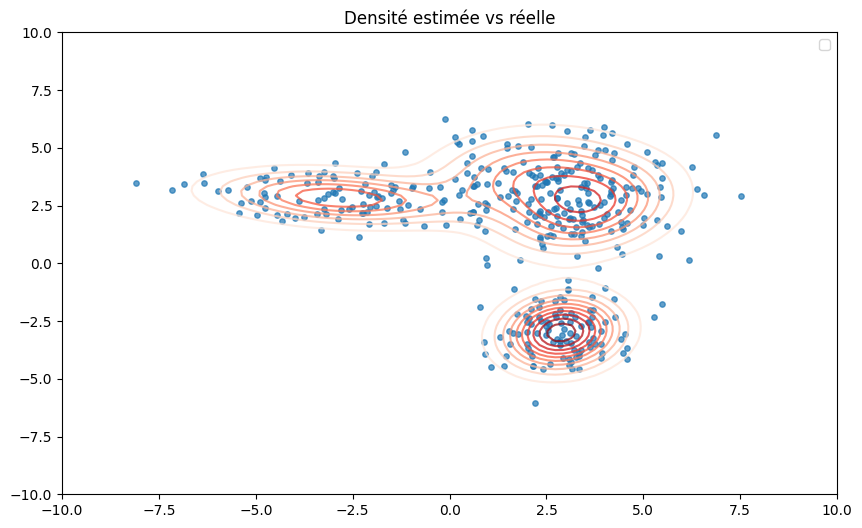

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


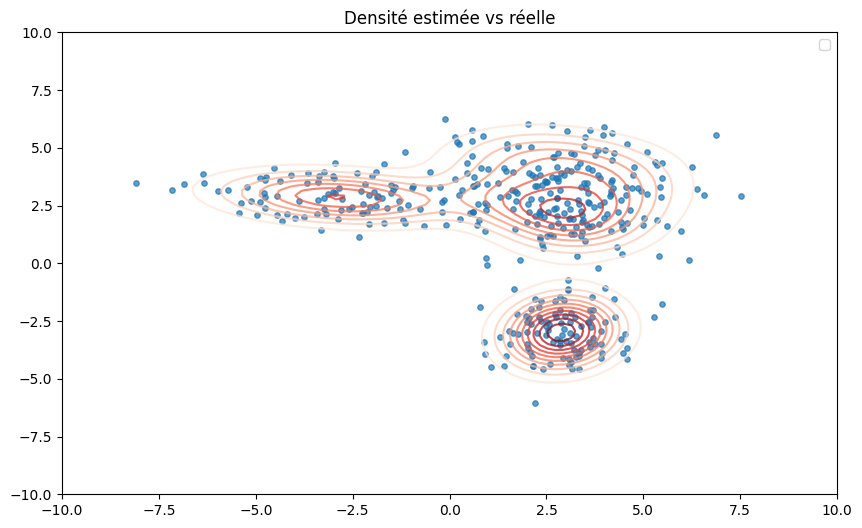

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


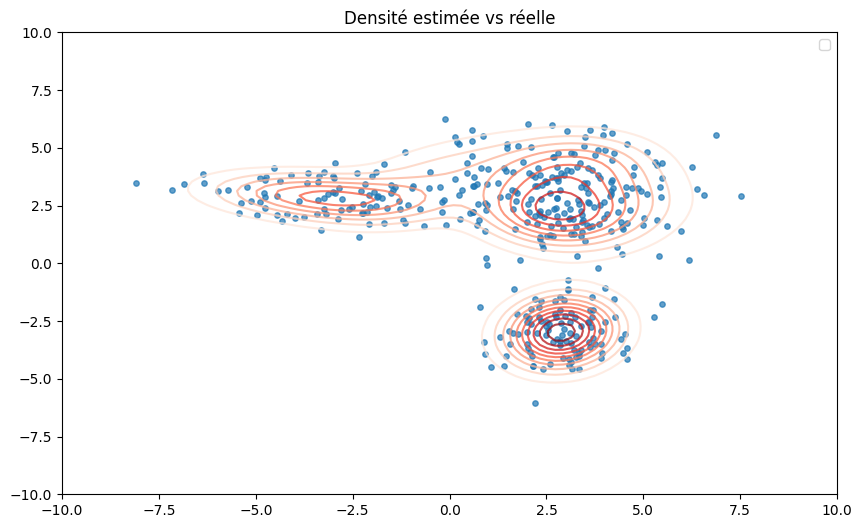

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


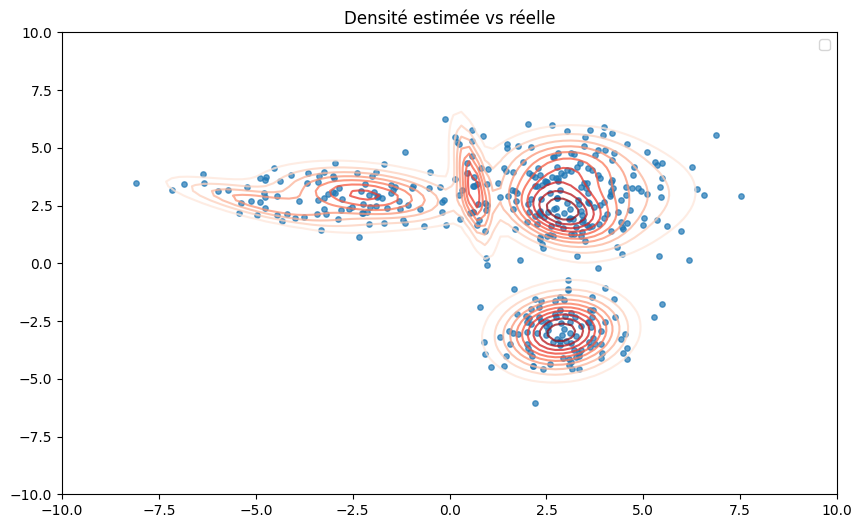

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


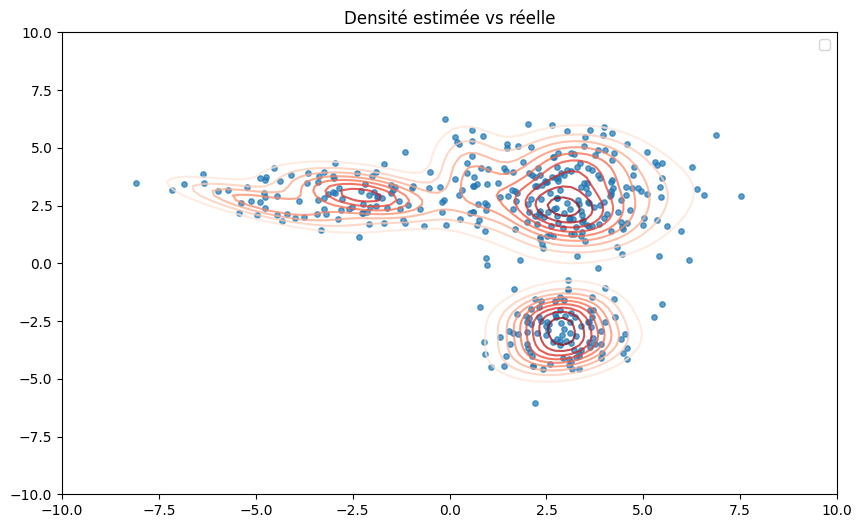

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


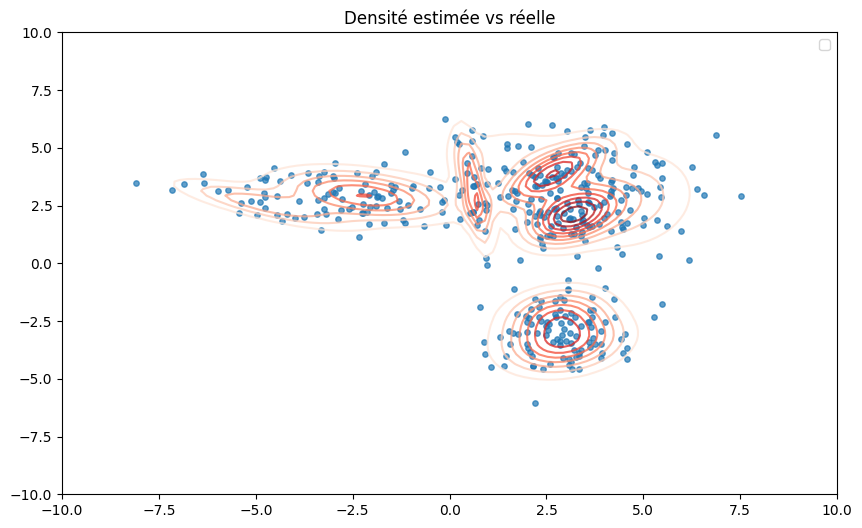

In [75]:
for i in range(4, 10):
    gmm2D2 = GaussianMixture(n_components=i, random_state=1)
    gmm2D2.fit(md)
    log_ = gmm2D2.score_samples(xy)
    dens = np.exp(log_).reshape(x.shape)

    plt.figure(figsize=(10, 6))
    plt.scatter(md[:,0], md[:, 1], alpha=0.7, s=15)
    plt.contour(x, y, dens, levels=10, cmap="Reds", linewidths=1.5, alpha=0.75)

    plt.title('Densité estimée vs réelle')
    plt.legend()
    plt.show()

## C. Données réelles (64D) - application en classification - synthèse

In [86]:
digits = load_digits()
X_dig = digits.data
y_dig = digits.target
X_train, X_test, y_train, y_test = train_test_split(X_dig, y_dig, test_size=0.3)